In [8]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi 
spec.loader.exec_module(lumapi)

import lumapi

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [9]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [10]:
fdtdApi = lumapi.FDTD(hide=False)

#units

um = 1e-6
nm = 1e-9

## Specifying the device and solver dimensions, materials and properties ##

In [11]:
#Materials
material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'

#Device dimensions

H = 400 * nm
w1 = 1.5 * um
w2 = 0.8 * um
Lp = 22.4 * um
Lp2 = 215 * um
Lp_array = np.linspace(0,300,9)*um
base_width = 4.5*um
waveguide_length = 16*um

#Solver and mesh dimensions

x_span_solver = Lp + 3/2 * waveguide_length
y_span_solver = 3*base_width
z_span_solver = 3*H

#Solver and mesh parameters

simulation_time = 5*(Lp + 2*waveguide_length)/c
mesh_accuracy = 2

def mode_selection(n):
    if n == 1:
        return 'fundamental mode'
    elif n == 2:
        return 'fundamental TE mode'
    elif n == 3:
        return 'fundamental TM mode'
    else:
        raise Exception('Invalid mode selection')


## Building the device ##

In [12]:
fdtdApi.addrect()
fdtdApi.set('name', 'rect_1')
fdtdApi.set('x max', -Lp/2)
fdtdApi.set('x min', -Lp/2 - waveguide_length)
fdtdApi.set('y', 0)
fdtdApi.set('y span', w1)
fdtdApi.set('z min', 0)
fdtdApi.set('z max', H/2)
fdtdApi.set('material', material)

fdtdApi.addrect()
fdtdApi.set('name', 'rect_2')
fdtdApi.set('x min', Lp/2)
fdtdApi.set('x max', Lp/2 + waveguide_length)
fdtdApi.set('y', 0)
fdtdApi.set('y span', w2)
fdtdApi.set('z min', 0)
fdtdApi.set('z max', H/2)
fdtdApi.set('material', material)

fdtdApi.addobject('linear_taper')
fdtdApi.set('name', 'taper')
fdtdApi.set('x', 0)
fdtdApi.set('y', 0)
fdtdApi.set('len', Lp)
fdtdApi.set('width_l', w1)
fdtdApi.set('width_r', w2)
fdtdApi.set('z', H/4)
fdtdApi.set('thickness', H/2)

fdtdApi.addrect()
fdtdApi.set('name', 'base')
fdtdApi.set('x', 0)
fdtdApi.set('x span', Lp + 2 * waveguide_length)
fdtdApi.set('y', 0)
fdtdApi.set('y span', base_width)
fdtdApi.set('z max', 0)
fdtdApi.set('z min', -H/2)
fdtdApi.set('material', material)

fdtdApi.addfdtd()
fdtdApi.set('x', 0)
fdtdApi.set('x span', x_span_solver)
fdtdApi.set('y', 0)
fdtdApi.set('y span', y_span_solver)
fdtdApi.set('z', 0)
fdtdApi.set('z span', z_span_solver)
fdtdApi.set('background material', sub_material)
fdtdApi.set('Mesh accuracy', mesh_accuracy)
fdtdApi.set('simulation time', simulation_time)
fdtdApi.set('global source wavelength start', 1500*nm)
fdtdApi.set('global source wavelength stop', 1600*nm)
fdtdApi.set('global monitor frequency points', 21)

fdtdApi.addprofile()
fdtdApi.set('name', 'profile')
fdtdApi.set('x', 0)
fdtdApi.set('y', 0)
fdtdApi.set('x', 0)
fdtdApi.set('x span', x_span_solver)
fdtdApi.set('y span', y_span_solver)

fdtdApi.addport()
fdtdApi.set('name', 'port_1')
fdtdApi.set('x', -x_span_solver/2)
fdtdApi.set('y', 0)
fdtdApi.set('y span', 2*base_width)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)
fdtdApi.set('mode selection', mode_selection(3))

fdtdApi.addport()
fdtdApi.set('name', 'port_2')
fdtdApi.set('x', x_span_solver/2)
fdtdApi.set('y', 0)
fdtdApi.set('y span', 2*base_width)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)

fdtdApi.addpower()
fdtdApi.set('name', 'power_monitor')
fdtdApi.set('monitor type', 5)
fdtdApi.set('x', x_span_solver/2 - 1*um)
fdtdApi.set('y', 0)
fdtdApi.set('y span', 2*base_width)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)

fdtdApi.addmodeexpansion()
fdtdApi.set('name', 'mode_expansion_monitor')
fdtdApi.set('x', x_span_solver/2 - 2*um)
fdtdApi.set('y', 0)
fdtdApi.set('y span', 2*base_width)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)
fdtdApi.set('mode selection', 'user select')
fdtdApi.set('selected mode numbers', 3)
fdtdApi.set('use wavelength spacing', 1)
fdtdApi.set('wavelength center', 1550*nm)
fdtdApi.set('wavelength span', 100*nm)
fdtdApi.set('frequency points', 21)
fdtdApi.setexpansion('Power_monitor', 'power_monitor')

fdtdApi.save('RIB_conversor_FDTD_2')

## Raising the mode conversion efficiency ($\eta$) x taper length graph ##

In [ ]:
eta_array = np.zeros(len(Lp_array))

for i in range(0, len(Lp_array),1):
    print('Execution: %d/%d' %(i+1, len(Lp_array)))
    fdtdApi.switchtolayout()
    fdtdApi.setnamed('rect_1', 'x', -Lp_array[i]/2 - waveguide_length/2)
    fdtdApi.setnamed('rect_2', 'x', Lp_array[i]/2 + waveguide_length/2)
    fdtdApi.setnamed('taper', 'len', Lp_array[i])
    fdtdApi.setnamed('base', 'x span', Lp_array[i] + 2 * waveguide_length)
    fdtdApi.setnamed('FDTD', 'x span', Lp_array[i] + 3/2 * waveguide_length)
    fdtdApi.setnamed('FDTD', 'simulation time', 5*(Lp_array[i] + 2 * waveguide_length)/c)
    fdtdApi.setnamed('profile', 'x span', Lp_array[i] + 3/2 * waveguide_length)
    fdtdApi.setnamed('FDTD::ports::port_1', 'x', -Lp_array[i]/2 - 3/4 * waveguide_length)
    fdtdApi.setnamed('FDTD::ports::port_2', 'x', Lp_array[i]/2 + 3/4 * waveguide_length)
    fdtdApi.setnamed('power_monitor', 'x', Lp_array[i]/2 + 3/4 * waveguide_length - 1*um)
    fdtdApi.setnamed('mode_expansion_monitor', 'x', Lp_array[i]/2 + 3/4 * waveguide_length - 2*um)
    fdtdApi.run()
    eta_array[i] = fdtdApi.getresult('mode_expansion_monitor', 'expansion for Power_monitor')['T_forward'][10][0]

Execution: 1/9
Execution: 2/9
Execution: 3/9
Execution: 4/9
Execution: 5/9
Execution: 6/9
Execution: 7/9
Execution: 8/9
Execution: 9/9


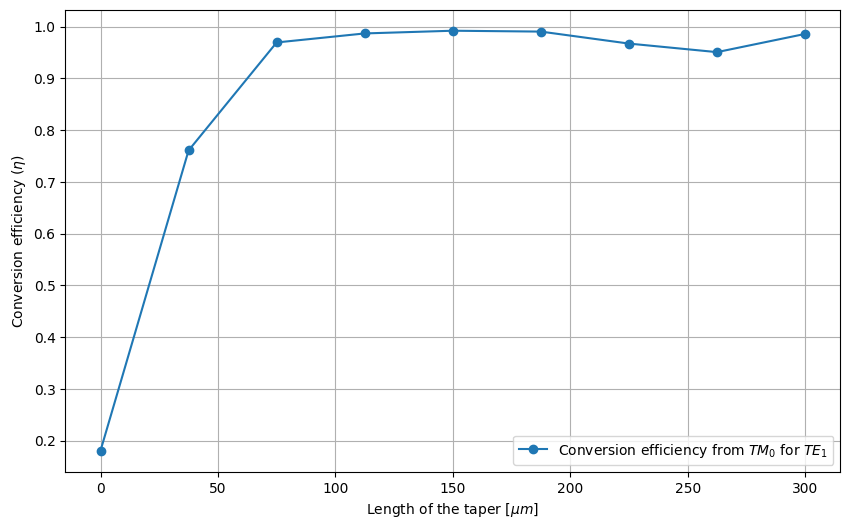

In [14]:
fig = plt.figure(figsize = (10,6))
plt.plot(Lp_array/um, eta_array, 'o-', label = r'Conversion efficiency from $TM_0$ for $TE_1$')
plt.xlabel(r'Length of the taper [$\mu m$]')
plt.ylabel(r'Conversion efficiency ($\eta$)')
plt.legend(loc = 'best')
plt.grid(True)
plt.show()

## Viewing the mode conversion ##

In [240]:
fdtdApi.switchtolayout()
fdtdApi.setnamed('FDTD', 'Mesh accuracy', 3)

### For a taper with 22.4 $\mu m$  of length ###

In [241]:
fdtdApi.setnamed('rect_1', 'x', -Lp/2 - waveguide_length/2)
fdtdApi.setnamed('rect_2', 'x', Lp/2 + waveguide_length/2)
fdtdApi.setnamed('taper', 'len', Lp)
fdtdApi.setnamed('base', 'x span', Lp + 2 * waveguide_length)
fdtdApi.setnamed('FDTD', 'x span', Lp + 3/2 * waveguide_length)
fdtdApi.setnamed('FDTD', 'simulation time', 5*(Lp + 2 * waveguide_length)/c)
fdtdApi.setnamed('profile', 'x span', Lp + 3/2 * waveguide_length)
fdtdApi.setnamed('FDTD::ports::port_1', 'x', -Lp/2 - 3/4 * waveguide_length)
fdtdApi.setnamed('FDTD::ports::port_1', 'mode selection', mode_selection(2))
fdtdApi.setnamed('FDTD::ports::port_2', 'x', Lp/2 + 3/4 * waveguide_length)
fdtdApi.setnamed('power_monitor', 'x', Lp/2 + 3/4 * waveguide_length - 1*um)
fdtdApi.setnamed('monitor', 'x', Lp/2 + 3/4 * waveguide_length - 2*um)

fdtdApi.run()

eField_22_TE = np.abs(np.squeeze(fdtdApi.getelectric('profile')))**2
eField_22_TE = eField_22_TE[:,:,10]

x_efield_22 = fdtdApi.getdata('profile', 'x')
y_efield_22 = fdtdApi.getdata('profile', 'y')

fdtdApi.switchtolayout()
fdtdApi.setnamed('FDTD::ports::port_1', 'mode selection', mode_selection(3))
fdtdApi.run()

eField_22_TM = np.abs(np.squeeze(fdtdApi.getelectric('profile')))**2
eField_22_TM = eField_22_TM[:,:,10]

In [264]:
eField_22_TE = eField_22_TE/np.max(eField_22_TE)
eField_22_TE_log = 10*np.log10(eField_22_TE)

eField_22_TM = eField_22_TM/np.max(eField_22_TM)
eField_22_TM_log = 10*np.log10(eField_22_TM)

xmin_22 = np.min(x_efield_22)
xmax_22 = np.max(x_efield_22)
ymin_22 = np.min(y_efield_22)
ymax_22 = np.max(y_efield_22)

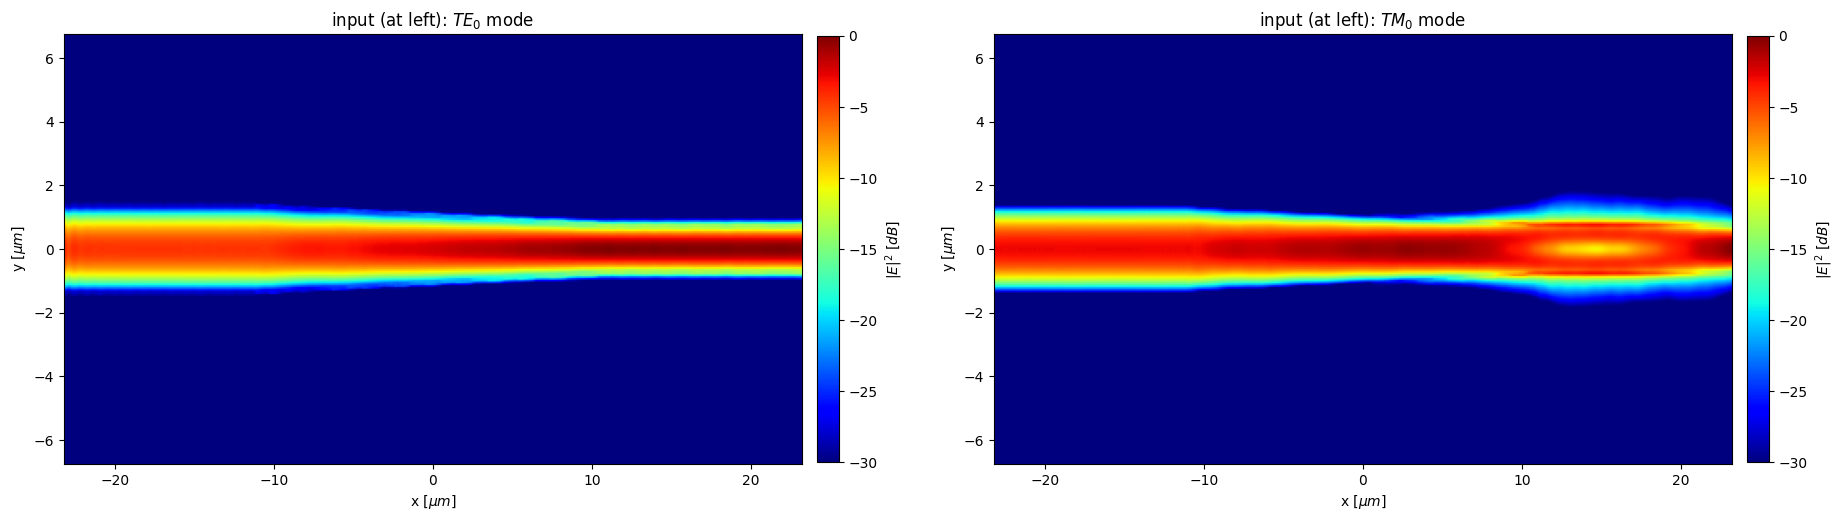

In [334]:
fig1, ax1 = plt.subplots(1,2, figsize=(22, 8))
im1 = ax1[0].imshow(np.rot90(eField_22_TE_log), vmin = -30, vmax = 0, cmap = plt.get_cmap('jet'), extent=[xmin_22/um, xmax_22/um, ymin_22/um, ymax_22/um])
fig1.colorbar(im1, ax = ax1[0], fraction = 0.0275, pad =0.02, label = r'$|E|^{2}$ $[dB]$')
ax1[0].set_xlabel(r'x [$\mu m$]')
ax1[0].set_ylabel(r'y [$\mu m$]')
ax1[0].set_title(r'input (at left): $TE_0$ mode')
ax1[0].set_aspect(2)

im2 = ax1[1].imshow(np.rot90(eField_22_TM_log), vmin = -30, vmax = 0, cmap = plt.get_cmap('jet'), extent=[xmin_22/um, xmax_22/um, ymin_22/um, ymax_22/um])
fig1.colorbar(im2, ax = ax1[1], fraction = 0.0275, pad =0.02, label = r'$|E|^{2}$ $[dB]$')
ax1[1].set_xlabel(r'x [$\mu m$]')
ax1[1].set_ylabel(r'y [$\mu m$]')
ax1[1].set_title(r'input (at left): $TM_0$ mode')
ax1[1].set_aspect(2)

plt.show()

### For a taper with 215 $\mu m$ of length ###

In [244]:
fdtdApi.switchtolayout()

fdtdApi.setnamed('rect_1', 'x', -Lp2/2 - waveguide_length/2)
fdtdApi.setnamed('rect_2', 'x', Lp2/2 + waveguide_length/2)
fdtdApi.setnamed('taper', 'len', Lp2)
fdtdApi.setnamed('base', 'x span', Lp2 + 2 * waveguide_length)
fdtdApi.setnamed('FDTD', 'x span', Lp2 + 3/2 * waveguide_length)
fdtdApi.setnamed('FDTD', 'simulation time', 5*(Lp2 + 2 * waveguide_length)/c)
fdtdApi.setnamed('profile', 'x span', Lp2 + 3/2 * waveguide_length)
fdtdApi.setnamed('FDTD::ports::port_1', 'x', -Lp2/2 - 3/4 * waveguide_length)
fdtdApi.setnamed('FDTD::ports::port_1', 'mode selection', mode_selection(2))
fdtdApi.setnamed('FDTD::ports::port_2', 'x', Lp2/2 + 3/4 * waveguide_length)
fdtdApi.setnamed('power_monitor', 'x', Lp2/2 + 3/4 * waveguide_length - 1*um)
fdtdApi.setnamed('monitor', 'x', Lp2/2 + 3/4 * waveguide_length - 2*um)

fdtdApi.run()

eField_215_TE = np.abs(np.squeeze(fdtdApi.getelectric('profile')))**2
eField_215_TE = eField_215_TE[:,:,10]

x_efield_215 = fdtdApi.getdata('profile', 'x')
y_efield_215 = fdtdApi.getdata('profile', 'y')

fdtdApi.switchtolayout()
fdtdApi.setnamed('FDTD::ports::port_1', 'mode selection', mode_selection(3))
fdtdApi.run()

eField_215_TM = (np.abs(np.squeeze(fdtdApi.getelectric('profile')))**2)
eField_215_TM = eField_215_TM[:,:,10]

In [262]:
eField_215_TE = eField_215_TE/np.max(eField_215_TE)
eField_215_TE_log = 10*np.log10(eField_215_TE)

eField_215_TM = eField_215_TM/np.max(eField_215_TM)
eField_215_TM_log = 10*np.log10(eField_215_TM)

xmin_215 = np.min(x_efield_215)
xmax_215 = np.max(x_efield_215)
ymin_215 = np.min(y_efield_215)
ymax_215 = np.max(y_efield_215)

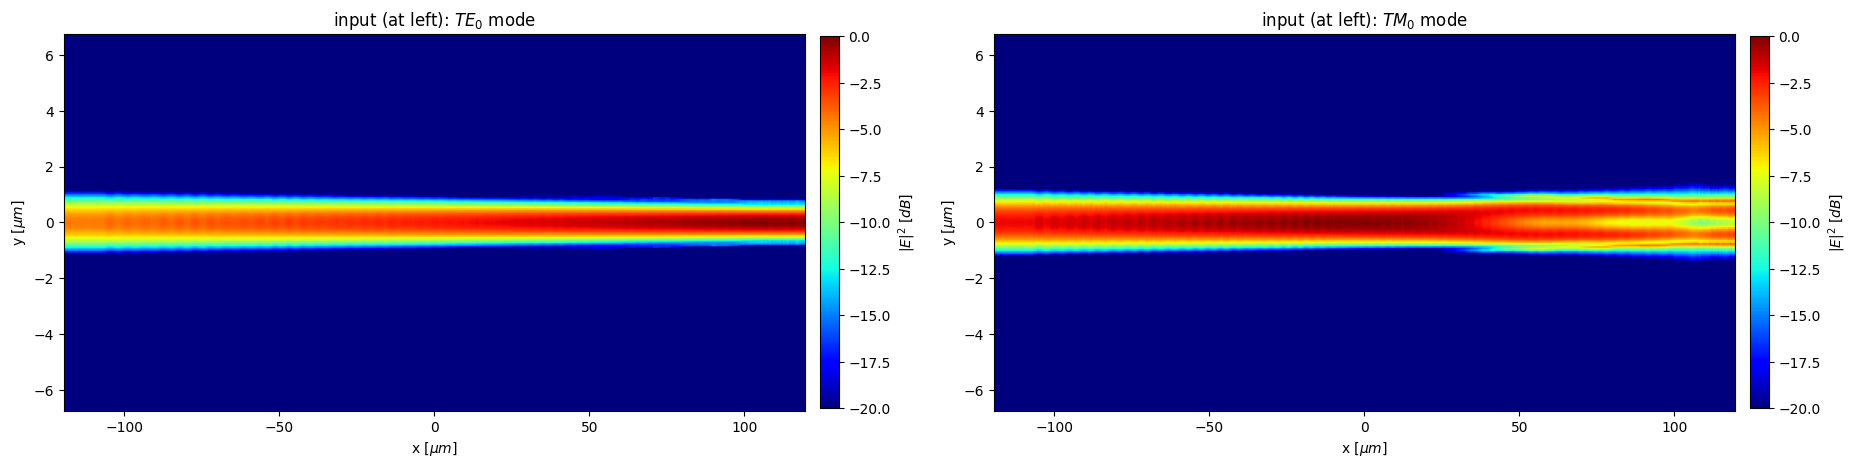

In [335]:
fig2, ax2 = plt.subplots(1,2, figsize=(22, 8))
im3 = ax2[0].imshow(np.rot90(eField_215_TE_log), vmin = -20, vmax = 0, cmap = plt.get_cmap('jet'), extent=[xmin_215/um, xmax_215/um, ymin_215/um, ymax_215/um])
fig2.colorbar(im3, ax = ax2[0], fraction = 0.024, pad =0.02, label = r'$|E|^{2}$ $[dB]$')
ax2[0].set_xlabel(r'x [$\mu m$]')
ax2[0].set_ylabel(r'y [$\mu m$]')
ax2[0].set_title(r'input (at left): $TE_0$ mode')
ax2[0].set_aspect(9)

im4 = ax2[1].imshow(np.rot90(eField_215_TM_log), vmin = -20, vmax = 0, cmap = plt.get_cmap('jet'), extent=[xmin_215/um, xmax_215/um, ymin_215/um, ymax_215/um])
fig2.colorbar(im4, ax = ax2[1], fraction = 0.024, pad =0.02, label = r'$|E|^{2}$ $[dB]$')
ax2[1].set_xlabel(r'x [$\mu m$]')
ax2[1].set_ylabel(r'y [$\mu m$]')
ax2[1].set_title(r'input (at left): $TM_0$ mode')
ax2[1].set_aspect(9)

plt.show()

In [15]:
fdtdApi.close()